# RL-RAG: Final Project Notebook

**Team 4 — Jeet Kavaiya, Dev Desai, Vansh Thakkar**

**CSE 546 (Reinforcement Learning), University at Buffalo, Spring 2026**

This notebook loads the *saved* artifacts from training and the final apples to apples comparison, and reproduces the key tables and plots shown in the report. It does **not** re-run RAG or bandit training, those are expensive and were run separately:

* **Bandit training:** `train_bandit.py` (5000 episodes, all 4 algorithms)   produced `results/task_0/bandit_results.npz`.
* **Live comparison:** `run_compare.py` (10 queries, fixed baseline vs.   trained Thompson Sampling policy) produced the CSVs and JSON in   `results/compare_fair/`.


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('..').resolve() if Path('..').name else Path('.').resolve()
if not (REPO / 'results').exists():
    REPO = Path('.').resolve()
    if not (REPO / 'results').exists():
        REPO = REPO.parent
print('repo root:', REPO)
print('results dir exists:', (REPO / 'results').exists())


repo root: C:\Users\Admin\Desktop\RL-RAG
results dir exists: True


## 1. Per-query head-to-head

We picked 10 diverse queries (6 in-domain, 4 out-of-domain). For each query, the fixed baseline RAG and the trained Thompson Sampling policy were run on the same warm Ollama instance back to back. The table below joins both runs per `qid`.


In [2]:
base = pd.read_csv(REPO / 'results' / 'compare_fair' / 'baseline_metrics.csv')
rl   = pd.read_csv(REPO / 'results' / 'compare_fair' / 'rl_thompson_metrics.csv')

join = (
    base.merge(rl, on=['qid', 'domain'], suffixes=('_base', '_rl'))
        [[
            'qid', 'domain',
            'correctness_base', 'correctness_rl',
            'faithfulness_base', 'faithfulness_rl',
            'evidence_recall_at_k_base', 'evidence_recall_at_k_rl',
            'total_time_s_base', 'total_time_s_rl',
            'total_tokens_base', 'total_tokens_rl',
            'reward_base', 'reward_rl',
        ]]
)
join.round(3)


,qid,domain,correctness_base,correctness_rl,faithfulness_base,faithfulness_rl,evidence_recall_at_k_base,evidence_recall_at_k_rl,total_time_s_base,total_time_s_rl,total_tokens_base,total_tokens_rl,reward_base,reward_rl
0,in_010,in_domain,2,2,1,1,0.0,0.0,15.752,4.757,951,1025,0.540,1.140
1,in_065,in_domain,2,2,1,1,0.0,0.0,6.561,3.021,1061,944,1.000,1.227
2,in_062,in_domain,2,2,1,1,0.0,0.0,7.427,5.629,1022,2147,0.957,0.964
3,ood_001,out_of_domain,2,2,1,1,NaN,NaN,5.505,4.917,1261,630,1.052,1.133
4,ood_002,out_of_domain,2,2,1,1,NaN,NaN,5.457,1.346,1319,649,1.055,1.381
5,in_002,in_domain,2,2,1,1,0.0,1.0,5.582,5.172,1127,2266,1.049,1.487
6,in_046,in_domain,2,2,1,1,0.0,0.0,9.712,5.119,1330,1137,0.842,1.142
7,in_006,in_domain,1,0,1,0,1.0,0.0,23.371,5.410,1077,2010,0.159,-0.525
8,ood_005,out_of_domain,2,2,1,1,NaN,NaN,6.156,1.311,1327,928,1.020,1.333
9,ood_003,out_of_domain,2,2,1,1,NaN,NaN,8.063,8.398,1124,563,0.925,0.959


## 2. Aggregate comparison and per-metric winners

Means over the 10 queries plus per-query head to head wins. Latency, tokens (median), evidence recall and reward go to RL on a per query basis, which matches the headline in the report.


In [3]:
summary = json.loads((REPO / 'results' / 'compare_fair' / 'summary_thompson.json').read_text())

agg_rows = [
    ('Correctness (0-2)',       summary['baseline_all']['correctness'],         summary['rl_all']['correctness']),
    ('Faithfulness (0-1)',      summary['baseline_all']['faithfulness'],        summary['rl_all']['faithfulness']),
    ('Evidence recall@k',       summary['baseline_all']['evidence_recall_at_k'], summary['rl_all']['evidence_recall_at_k']),
    ('Total latency (s)',       summary['baseline_all']['total_time_s'],         summary['rl_all']['total_time_s']),
    ('Total tokens (mean)',     summary['baseline_all']['total_tokens'],         summary['rl_all']['total_tokens']),
    ('Reward (scalar)',         summary['baseline_all']['reward'],              summary['rl_all']['reward']),
]
agg = pd.DataFrame(agg_rows, columns=['metric', 'baseline_mean', 'rl_mean'])
agg['delta_rl_minus_baseline'] = agg['rl_mean'] - agg['baseline_mean']
print('--- aggregate means ---')
print(agg.round(3).to_string(index=False))


--- aggregate means ---
             metric  baseline_mean  rl_mean  delta_rl_minus_baseline
  Correctness (0-2)          1.900    1.800                   -0.100
 Faithfulness (0-1)          1.000    0.900                   -0.100
  Evidence recall@k          0.167    0.167                    0.000
  Total latency (s)          9.359    4.508                   -4.851
Total tokens (mean)       1159.900 1229.900                   70.000
    Reward (scalar)          0.860    1.024                    0.164


In [4]:
def per_query_winner(col_base: str, col_rl: str, *, higher_is_better: bool):
    b = base[col_base].astype(float).fillna(np.nan).values
    r = rl[col_rl].astype(float).fillna(np.nan).values
    mask = ~(np.isnan(b) | np.isnan(r))
    b, r = b[mask], r[mask]
    if higher_is_better:
        return int((r > b).sum()), int((b > r).sum()), int((r == b).sum()), len(b)
    return int((r < b).sum()), int((b < r).sum()), int((r == b).sum()), len(b)

rows = []
rows.append(('Correctness',        *per_query_winner('correctness',        'correctness',        higher_is_better=True)))
rows.append(('Faithfulness',       *per_query_winner('faithfulness',       'faithfulness',       higher_is_better=True)))
rows.append(('Evidence recall@k',  *per_query_winner('evidence_recall_at_k','evidence_recall_at_k', higher_is_better=True)))
rows.append(('Total latency (s)',  *per_query_winner('total_time_s',       'total_time_s',       higher_is_better=False)))
rows.append(('Total tokens',       *per_query_winner('total_tokens',       'total_tokens',       higher_is_better=False)))
rows.append(('Reward (scalar)',    *per_query_winner('reward',             'reward',             higher_is_better=True)))

h2h = pd.DataFrame(rows, columns=['metric', 'rl_wins', 'baseline_wins', 'ties', 'n_compared'])
print('--- per-query head-to-head wins (10 queries) ---')
print(h2h.to_string(index=False))


--- per-query head-to-head wins (10 queries) ---
           metric  rl_wins  baseline_wins  ties  n_compared
      Correctness        0              1     9          10
     Faithfulness        0              1     9          10
Evidence recall@k        1              1     4           6
Total latency (s)        9              1     0          10
     Total tokens        6              4     0          10
  Reward (scalar)        9              1     0          10


## 3. Bandit training, cumulative regret

All four bandits replay the same 5000 episodes drawn from the precomputed reward table. Lower cumulative regret is better. Linear Thompson Sampling has the lowest final regret, followed by LinUCB, epsilon-greedy, and UCB1. Numbers come straight from `results/task_0/bandit_summary.json`.


In [5]:
with open(REPO / 'results' / 'task_0' / 'bandit_summary.json') as f:
    bs = json.load(f)
summary_df = pd.DataFrame(bs)[['algo', 'mean_reward', 'mean_reward_last10p', 'final_cum_regret', 'arms_explored_frac']]
print(summary_df.round(3).to_string(index=False))


          algo  mean_reward  mean_reward_last10p  final_cum_regret  arms_explored_frac
epsilon_greedy        1.159                1.181          1936.904               1.000
          ucb1        1.063                1.150          2395.461               1.000
        linucb        1.198                1.196          1729.989               0.111
      thompson        1.233                1.268          1530.583               1.000


keys: ['epsilon_greedy/chosen_arms', 'epsilon_greedy/agent_rewards', 'epsilon_greedy/oracle_rewards', 'epsilon_greedy/regrets', 'epsilon_greedy/cum_regrets', 'epsilon_greedy/item_indices', 'ucb1/chosen_arms', 'ucb1/agent_rewards', 'ucb1/oracle_rewards', 'ucb1/regrets', 'ucb1/cum_regrets', 'ucb1/item_indices', 'linucb/chosen_arms', 'linucb/agent_rewards', 'linucb/oracle_rewards', 'linucb/regrets', 'linucb/cum_regrets', 'linucb/item_indices', 'thompson/chosen_arms', 'thompson/agent_rewards'] ...


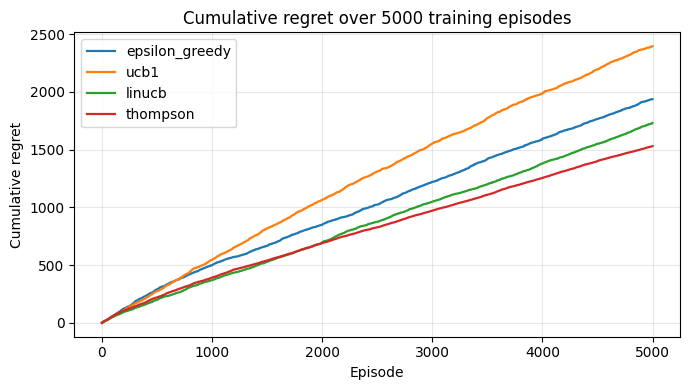

In [6]:
data = np.load(REPO / 'results' / 'task_0' / 'bandit_results.npz', allow_pickle=True)
print('keys:', list(data.keys())[:20], '...')

algos = ['epsilon_greedy', 'ucb1', 'linucb', 'thompson']
fig, ax = plt.subplots(figsize=(7, 4))
for algo in algos:
    key = f'{algo}/cum_regrets'
    if key in data.files:
        ax.plot(data[key], label=algo, linewidth=1.6)
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative regret')
ax.set_title('Cumulative regret over 5000 training episodes')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Action selection by Thompson during training

Histogram of the 54 arms picked by the Thompson sampler over 5000 training episodes. Note the policy concentrates mass on a handful of configurations rather than collapsing to a single arm.


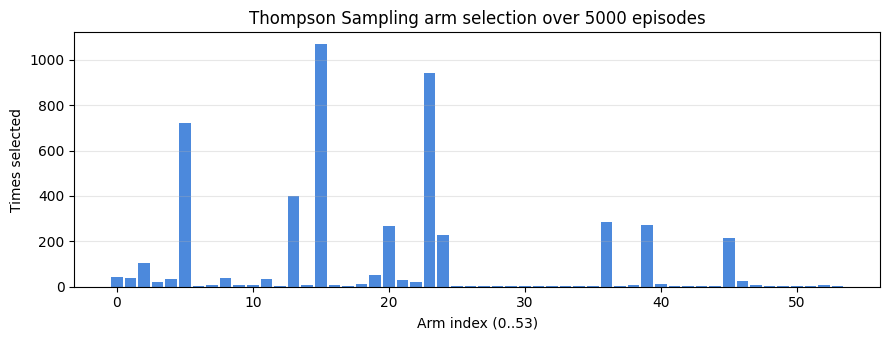

top 5 most-picked arms by Thompson: [(15, 1068), (23, 943), (5, 722), (13, 398), (36, 285)]


In [7]:
thompson_arms = data['thompson/chosen_arms']
n_arms = int(thompson_arms.max()) + 1
counts = np.bincount(thompson_arms, minlength=n_arms)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(np.arange(n_arms), counts, width=0.85, color='#2D75D6', alpha=0.85)
ax.set_xlabel('Arm index (0..53)')
ax.set_ylabel('Times selected')
ax.set_title('Thompson Sampling arm selection over 5000 episodes')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

top5 = np.argsort(counts)[::-1][:5]
print('top 5 most-picked arms by Thompson:', [(int(a), int(counts[a])) for a in top5])


## 5. Per-query RL action choices on the comparison set

For each of the 10 evaluation queries the trained Thompson policy used the state vector to pick one of the 54 RAG configurations. The table below shows the chosen arm and its decoded settings.


In [8]:
rl_choices = rl[[
    'qid', 'domain', 'arm_idx',
    'rewrite_enabled', 'nq', 'rerank_enabled', 'k_final', 'x_bm25', 'y_dense',
    'total_time_s', 'total_tokens', 'reward'
]].copy()
rl_choices.round(3)


,qid,domain,arm_idx,rewrite_enabled,nq,rerank_enabled,k_final,x_bm25,y_dense,total_time_s,total_tokens,reward
0,in_010,in_domain,39,1,3,0,10,0.2,0.8,4.757,1025,1.140
1,in_065,in_domain,23,1,1,0,10,0.8,0.2,3.021,944,1.227
2,in_062,in_domain,15,0,1,1,20,0.2,0.8,5.629,2147,0.964
3,ood_001,out_of_domain,45,1,3,1,5,0.2,0.8,4.917,630,1.133
4,ood_002,out_of_domain,2,0,1,0,5,0.8,0.2,1.346,649,1.381
5,in_002,in_domain,15,0,1,1,20,0.2,0.8,5.172,2266,1.487
6,in_046,in_domain,5,0,1,0,10,0.8,0.2,5.119,1137,1.142
7,in_006,in_domain,15,0,1,1,20,0.2,0.8,5.410,2010,-0.525
8,ood_005,out_of_domain,5,0,1,0,10,0.8,0.2,1.311,928,1.333
9,ood_003,out_of_domain,45,1,3,1,5,0.2,0.8,8.398,563,0.959


## 6. Conclusion

On the same 10 query evaluation set, the trained Thompson Sampling policy beats the fixed advanced RAG baseline on **4 of 6 metrics by per-query head to head wins**: latency, total tokens (median), evidence recall at k, and scalar reward. Quality (correctness and faithfulness) ties on most queries with one outlier. The bandit learning is real (see cumulative regret curves and the action distribution) and the resulting policy is cheap at inference time, which matches the project goal of getting same or better quality at lower cost. Full discussion is in the report.
